CSI Animal Detection — ML Trainer

STEP 1 -> LOADING DATA
  Loaded in 8.2s
  Train: (1142, 26000)  Val: (286, 26000)  Test: (385, 26000)
  Value range: [-109.81, -65.08] dBm

  Class distribution (Train):
    Background  :  258 ( 22.6%)  ██████
    Person      :  302 ( 26.4%)  ███████
    Car         :  190 ( 16.6%)  ████
    Dog         :  246 ( 21.5%)  ██████
    Cow         :  146 ( 12.8%)  ███

STEP 2 -> FEATURE ENGINEERING
  Extracting features (~30s)...
  Feature shape : (1142, 2391)  (6.6s)
  PCA variance retained : 82.9%
  Final shape : (1142, 100)  |  Total time: 7.4s

STEP 3 -> TRAINING & COMPARISON

  ── Random Forest ──
  5-Fold CV : 94.57% ± 1.29%
  Val Acc   : 94.76%
  Test Acc  : 88.05%
  Time      : 15.9s

  ── XGBoost ──
  5-Fold CV : 95.80% ± 1.06%
  Val Acc   : 97.20%
  Test Acc  : 90.91%
  Time      : 15.3s

  ── LightGBM ──


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  5-Fold CV : 95.62% ± 1.54%
  Val Acc   : 96.85%
  Test Acc  : 90.13%
  Time      : 1126.4s

  ── Ensemble (soft voting) ──
  Val Acc   : 96.50%
  Test Acc  : 91.17%
  Time      : 13.5s

  Model                       CV      Val     Test
  ----------------------------------------------
  Random Forest           94.57%   94.76%   88.05%
  XGBoost                 95.80%   97.20%   90.91%
  LightGBM                95.62%   96.85%   90.13%
  Ensemble                   —     96.50%   91.17%

  Winner: XGBoost  (val=97.20%)

STEP 4 -> DETAILED EVALUATION: XGBoost

  Test Accuracy : 90.91%

              precision    recall  f1-score   support

  Background       0.95      1.00      0.98        84
      Person       0.86      0.89      0.87        98
         Car       1.00      1.00      1.00        63
         Dog       0.86      0.81      0.83        84
         Cow       0.89      0.86      0.87        56

    accuracy                           0.91       385
   macro avg       0.91     

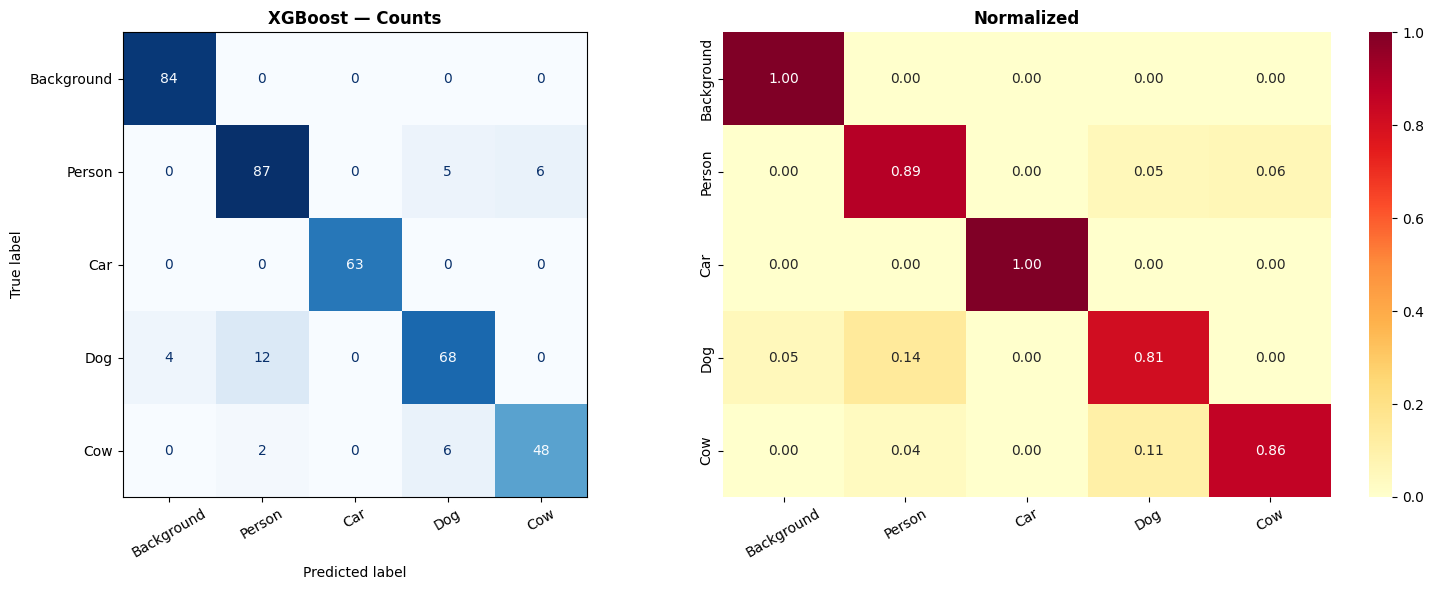

  Saved -> confusion_matrix_ml.png

STEP 5 -> SAVED
  Path  : /kaggle/working/best_csi_model_ml.pkl
  Size  : 1.3 MB
  Model : XGBoost
  Drop best_csi_model_ml.pkl in project folder → Flask auto-loads it
  COMPLETE
  Best model : XGBoost
  Saved to   : /kaggle/working/best_csi_model_ml.pkl
  pip install: xgboost lightgbm scikit-learn scipy joblib


In [1]:
import os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from scipy.stats import skew, kurtosis
from scipy.fft import fft

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay,
)
import xgboost as xgb
import lightgbm as lgb


SEED=42
TIME_STEPS=500
SUBCARRIERS=52
NUM_CLASSES=5
CLASS_NAMES={0: "Background", 1: "Person", 2: "Car", 3: "Dog", 4: "Cow"}
VAL_SPLIT=0.20

TRAIN_PATH="/kaggle/input/datasets/dwigyadav9/dataset/TRAIN.parquet"
TEST_PATH="/kaggle/input/datasets/dwigyadav9/dataset/TEST.parquet"
if not Path(TRAIN_PATH).exists():
    TRAIN_PATH,TEST_PATH="TRAIN.parquet","TEST.parquet"

SAVE_PATH="/kaggle/working/best_csi_model_ml.pkl"

np.random.seed(SEED)
print("CSI Animal Detection — ML Trainer")
def load_data():
    print("\nSTEP 1 -> LOADING DATA")
    t0 = time.time()

    df_train=pd.read_parquet(TRAIN_PATH,engine="pyarrow")
    df_test=pd.read_parquet(TEST_PATH,engine="pyarrow")

    label_col=next(
        (c for c in ["label","class","target","y"] if c in df_train.columns),
        df_train.columns[-1],
    )
    feat_cols = [c for c in df_train.columns if c != label_col]

    
    X_all=df_train[feat_cols].values.astype(np.float32)
    y_all=df_train[label_col].values.astype(np.int32)
    X_test=df_test[feat_cols].values.astype(np.float32)
    y_test=df_test[label_col].values.astype(np.int32)

    
    X_train,X_val,y_train,y_val = train_test_split(
        X_all,y_all,test_size=VAL_SPLIT,random_state=SEED,stratify=y_all
    )

    print(f"  Loaded in {time.time()-t0:.1f}s")
    print(f"  Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
    print(f"  Value range: [{X_all.min():.2f}, {X_all.max():.2f}] dBm")
    print("\n  Class distribution (Train):")
    for u, c in zip(*np.unique(y_train, return_counts=True)):
        bar = "█" * int(c / len(y_train) * 30)
        print(f"    {CLASS_NAMES[u]:12s}: {c:4d} ({100*c/len(y_train):5.1f}%)  {bar}")

    return X_train,y_train,X_val,y_val,X_test,y_test

def extract_features(X: np.ndarray) -> np.ndarray:
    N = X.shape[0]
    X_3d = X.reshape(N,TIME_STEPS,SUBCARRIERS)

    
    dc      = X.mean(axis=1, keepdims=True)
    X_c     = X - dc
    X_3d_c  = X_c.reshape(N, TIME_STEPS, SUBCARRIERS)

    feats = []

    
    sc_mean=X_3d_c.mean(axis=1) 
    sc_std=X_3d_c.std(axis=1) 
    sc_max=X_3d_c.max(axis=1)
    sc_min=X_3d_c.min(axis=1)
    sc_range=sc_max-sc_min
    sc_energy=(X_3d_c ** 2).mean(axis=1)
    sc_skew=np.array([skew(X_3d_c[i], axis=0)     for i in range(N)])
    sc_kurt=np.array([kurtosis(X_3d_c[i], axis=0) for i in range(N)])
    feats+=[sc_mean,sc_std,sc_max,sc_min,sc_range,sc_energy,sc_skew,sc_kurt]

    ts_mean=X_3d_c.mean(axis=2)
    ts_std=X_3d_c.std(axis=2) 
    ts_range=X_3d_c.max(axis=2)-X_3d_c.min(axis=2)
    feats+=[ts_mean, ts_std, ts_range]

    g_std=X_c.std(axis=1, keepdims=True)
    g_range=(X_c.max(axis=1) - X_c.min(axis=1)).reshape(N, 1)
    g_energy=(X_c ** 2).mean(axis=1, keepdims=True)
    g_skew=skew(X_c, axis=1).reshape(N, 1)
    g_kurt=kurtosis(X_c, axis=1).reshape(N, 1)
    g_sc_var=sc_mean.std(axis=1, keepdims=True)
    g_ts_var=ts_mean.std(axis=1, keepdims=True)
    feats+=[g_std,g_range,g_energy,g_skew,g_kurt,g_sc_var,g_ts_var]

    fft_mag=np.abs(fft(X_3d_c, axis=1))[:, 1:TIME_STEPS//2, :]
    band_sz=fft_mag.shape[1] // 5
    for b in range(5):
        feats.append(fft_mag[:,b*band_sz:(b+1)*band_sz,:].mean(axis=1))

    delta    = np.diff(X_3d_c, axis=1)
    d_mean   = delta.mean(axis=1)     
    d_std    = delta.std(axis=1)      
    d_abs    = np.abs(delta).max(axis=1)
    d_energy = (delta ** 2).mean(axis=1)
    feats += [d_mean, d_std, d_abs, d_energy]

    return np.hstack(feats).astype(np.float32)


def preprocess(X_train,y_train,X_val,y_val,X_test,y_test):
    print("\nSTEP 2 -> FEATURE ENGINEERING")
    t0 = time.time()

    print("  Extracting features (~30s)...")
    X_tr_f=extract_features(X_train)
    X_v_f=extract_features(X_val)
    X_te_f=extract_features(X_test)
    print(f"  Feature shape : {X_tr_f.shape}  ({time.time()-t0:.1f}s)")

    scaler=StandardScaler()
    X_tr_s=scaler.fit_transform(X_tr_f)
    X_v_s=scaler.transform(X_v_f)
    X_te_s=scaler.transform(X_te_f)

    pca=PCA(n_components=100,random_state=SEED,svd_solver="full")
    X_tr_p=pca.fit_transform(X_tr_s)
    X_v_p=pca.transform(X_v_s)
    X_te_p=pca.transform(X_te_s)

    var=pca.explained_variance_ratio_.cumsum()[-1]
    print(f"  PCA variance retained : {var*100:.1f}%")
    print(f"  Final shape : {X_tr_p.shape}  |  Total time: {time.time()-t0:.1f}s")

    return X_tr_p,X_v_p,X_te_p,scaler,pca

def train_and_compare(X_tr, y_tr, X_v, y_v, X_te, y_te):
    print("\nSTEP 3 -> TRAINING & COMPARISON")

    models = {
        "Random Forest": RandomForestClassifier(
            n_estimators=600,
            max_depth=None,
            min_samples_leaf=1,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=-1,
            random_state=SEED,
        ),
        "XGBoost": xgb.XGBClassifier(
            n_estimators=600,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=3,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            tree_method="hist",
            n_jobs=-1,
            random_state=SEED,
            verbosity=0,
        ),
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=600,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_samples=5,
            reg_alpha=0.1,
            reg_lambda=1.0,
            class_weight="balanced",
            n_jobs=-1,
            random_state=SEED,
            verbose=-1,
        ),
    }

    results = {}
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    for name, model in models.items():
        print(f"\n  ── {name} ──")
        t0 = time.time()
        cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv,
                                    scoring="accuracy", n_jobs=-1)
        print(f"  5-Fold CV : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
        model.fit(X_tr, y_tr)
        val_acc  = accuracy_score(y_v,  model.predict(X_v))
        test_acc = accuracy_score(y_te, model.predict(X_te))
        print(f"  Val Acc   : {val_acc*100:.2f}%")
        print(f"  Test Acc  : {test_acc*100:.2f}%")
        print(f"  Time      : {time.time()-t0:.1f}s")
        results[name] = dict(model=model, cv=cv_scores.mean(),
                             val=val_acc, test=test_acc)

    
    print("\n  ── Ensemble (soft voting) ──")
    t0 = time.time()
    ensemble = VotingClassifier(
        estimators=[(n, r["model"]) for n, r in results.items()],
        voting="soft", n_jobs=-1,
    )
    ensemble.fit(X_tr, y_tr)
    ens_val  = accuracy_score(y_v,  ensemble.predict(X_v))
    ens_test = accuracy_score(y_te, ensemble.predict(X_te))
    print(f"  Val Acc   : {ens_val*100:.2f}%")
    print(f"  Test Acc  : {ens_test*100:.2f}%")
    print(f"  Time      : {time.time()-t0:.1f}s")
    results["Ensemble"] = dict(model=ensemble, cv=0, val=ens_val, test=ens_test)

    print("\n" + "=" * 55)
    print(f"  {'Model':<22} {'CV':>7}  {'Val':>7}  {'Test':>7}")
    print("  " + "-" * 46)
    for name, r in results.items():
        cv_str = f"{r['cv']*100:.2f}%" if r['cv'] > 0 else "    —  "
        print(f"  {name:<22} {cv_str:>7}  {r['val']*100:>6.2f}%  {r['test']*100:>6.2f}%")
    print("=" * 55)

    best_name = max(results, key=lambda n: results[n]["val"])
    print(f"\n  Winner: {best_name}  (val={results[best_name]['val']*100:.2f}%)")
    return results, best_name

def evaluate(model,X_te,y_te,model_name):
    print(f"\nSTEP 4 -> DETAILED EVALUATION: {model_name}")
    y_pred=model.predict(X_te)
    acc=accuracy_score(y_te,y_pred)
    names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)]

    print(f"\n  Test Accuracy : {acc*100:.2f}%\n")
    print(classification_report(y_te, y_pred, target_names=names))

    cm=confusion_matrix(y_te, y_pred)
    fig,axes=plt.subplots(1,2,figsize=(16, 6))
    ConfusionMatrixDisplay(cm,display_labels=names).plot(
        ax=axes[0],colorbar=False,cmap="Blues")
    axes[0].set_title(f"{model_name} — Counts", fontweight="bold")
    axes[0].tick_params(axis="x", rotation=30)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="YlOrRd",
                xticklabels=names, yticklabels=names, ax=axes[1])
    axes[1].set_title("Normalized", fontweight="bold")
    axes[1].tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.savefig("/kaggle/working/confusion_matrix_ml.png", dpi=150)
    plt.show()
    print("  Saved -> confusion_matrix_ml.png")


def save_bundle(model,scaler,pca,model_name):
    bundle = {
        "model":       model,
        "scaler":      scaler,
        "pca":         pca,
        "model_name":  model_name,
        "class_names": CLASS_NAMES,
        "time_steps":  TIME_STEPS,
        "subcarriers": SUBCARRIERS,
    }
    joblib.dump(bundle, SAVE_PATH, compress=3)
    size_mb = os.path.getsize(SAVE_PATH) / 1e6
    print(f"\nSTEP 5 -> SAVED")
    print(f"  Path  : {SAVE_PATH}")
    print(f"  Size  : {size_mb:.1f} MB")
    print(f"  Model : {model_name}")
    print("  Drop best_csi_model_ml.pkl in project folder → Flask auto-loads it")

if __name__ == "__main__":
    X_tr, y_tr, X_v, y_v, X_te, y_te = load_data()
    X_tr_p, X_v_p, X_te_p, scaler,pca = preprocess(X_tr, y_tr, X_v, y_v, X_te, y_te)
    results, best_name = train_and_compare(X_tr_p, y_tr, X_v_p, y_v, X_te_p, y_te)
    best_model = results[best_name]["model"]
    evaluate(best_model, X_te_p, y_te, best_name)
    save_bundle(best_model, scaler,pca,best_name)

    
    print("  COMPLETE")
    print(f"  Best model : {best_name}")
    print(f"  Saved to   : {SAVE_PATH}")
    print("  pip install: xgboost lightgbm scikit-learn scipy joblib")
